In [5]:
!pip install livelossplot
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 62.1 MB/s eta 0:00:00


In [6]:
# standard library imports
import os
import json
import shutil
import zipfile

# third-party library imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from google.colab import drive

# pytoch & utilities
import torch
import torch.nn as nn
import torch.cuda.amp as amp
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR

# torchvision
import torchvision
from torchvision import transforms, tv_tensors
from torchvision.transforms import v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# evaluation & logging
from livelossplot import PlotLosses
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [7]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda


In [8]:
"""
This cell loads the BDD100k dataset from Google Drive into
Google Colab's local working directory.
"""
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/COMP646_Final_Project/BDD100K.zip'
local_zip = '/content/BDD100k.zip'
extract_to = 'content/BDD100K'

shutil.copyfile(zip_path, local_zip)

with zipfile.ZipFile(local_zip, 'r') as zip_ref:
  zip_ref.extractall(extract_to)

Mounted at /content/drive


In [9]:
label_map = {
    'bike': 1,
    'bus': 2,
    'car': 3,
    'drivable area': 4,
    'lane': 5,
    'motor': 6,
    'person': 7,
    'rider': 8,
    'traffic light': 9,
    'traffic sign': 10,
    'train': 11,
    'truck': 12
}
num_classes = len(label_map)

In [10]:
"""
This cell defines all helper functions used in this notebook.
"""
def visualize_sample(img, boxes, labels, scores):
    """
    Visualizes the bounding boxes on an image
    """
    is_prediction = (scores is not None)
    id_to_label = {v: k for k, v in label_map.items()}
    fig, ax = plt.subplots(figsize=(15, 9))
    ax.imshow(img)

    for idx in range(len(boxes)):
      if is_prediction:
        if scores[idx] < 0.5:
          continue
      label = id_to_label[labels[idx]] if is_prediction else labels[idx]
      pts = boxes[idx]

      x_min, y_min = pts[0]
      x_max, y_max = pts[1]

      width, height = x_max - x_min, y_max - y_min
      rect = patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor='r', facecolor='none')
      ax.text(x_min, y_min - 2, label, color='white', fontsize=9, bbox=dict(facecolor='red', alpha=0.5))
      ax.add_patch(rect)

    ax.set_xlim(0, 1280)
    ax.set_ylim(720, 0)
    plt.axis('off')
    plt.show()

def collate_fn(batch):
    """
    Takes a list of tuples [(image, target)] and returns
    a tuple of lists ([image1, image2], [target1, target2])
    """
    return tuple(zip(*batch))

def get_model(num_classes):
    """
    Returns a FasterRCNN model with an untrained classifier
    """
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def load_model(path):
  """
  Returns a trained model using a checkpoint
  """
  checkpoint = torch.load(path, map_location=device)
  model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
  in_features = model.roi_heads.box_predictor.cls_score.in_features
  model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes + 1)
  model.load_state_dict(checkpoint['model_state_dict'])
  model.to(device)
  model.eval()
  return model

In [11]:
def load_bdd100k(split):
    merged_data = []

    base_path = "/content/content/BDD100K/BDD100K"

    image_dir = os.path.join(base_path, split, "img")
    annotation_dir = os.path.join(base_path, split, "ann")

    for file_name in os.listdir(image_dir):
        file_path = os.path.join(image_dir, file_name)

        with open(os.path.join(annotation_dir, f"{file_name}.json")) as file:
            json_annotations = json.load(file)
            cleaned_objects = []
            for obj in json_annotations["objects"]:
                cleaned_objects.append({
                    "coordinates": obj["points"]["exterior"],
                    "label": obj["classTitle"]
                })

        merged_data.append({
            "file_path": file_path,
            "scene_objects": cleaned_objects,
        })


    return merged_data

In [12]:
train_data = load_bdd100k('train')
test_data = load_bdd100k('val')

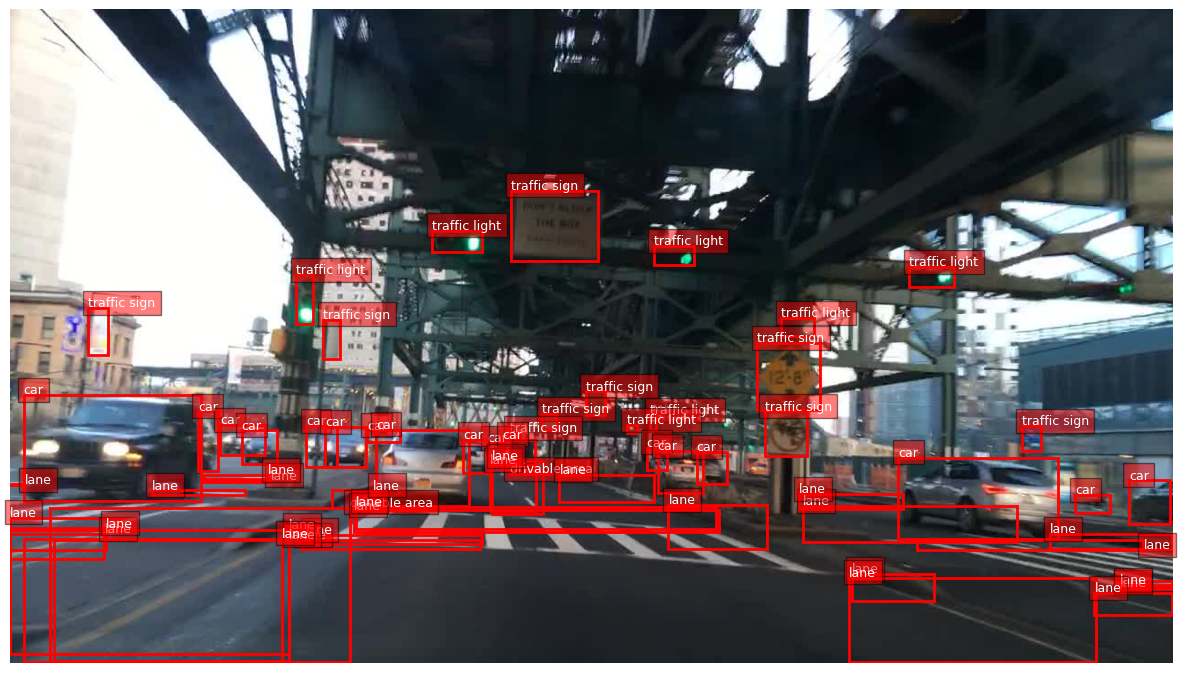

In [13]:
# visualize a random training sample
sample = train_data[3212]
img = Image.open(sample['file_path']).convert('RGB')
boxes = [obj['coordinates'] for obj in sample['scene_objects']]
labels = [obj['label'] for obj in sample['scene_objects']]
visualize_sample(img, boxes, labels, None)

In [14]:
class BDD100kDataset(Dataset):
    def __init__(self, data_list, label_map, short_edge=800, max_edge=1333, is_train=True):
        self.data = data_list
        self.label_map = label_map
        self.is_train = is_train

        # FasterRCNN PyTorch implementation normalizes the data such that the mean is zero.
        if self.is_train:
          self.transform = v2.Compose([
              v2.Resize(size=short_edge, max_size=max_edge),
              v2.RandomHorizontalFlip(p=0.5),
              v2.ToImage(),
              v2.ToDtype(torch.float32, scale=True)
          ])
        else:
          self.transform = v2.Compose([
              v2.Resize(size=short_edge, max_size=max_edge),
              v2.ToImage(),
              v2.ToDtype(torch.float32, scale=True)
          ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # 1. load the image.
        img = Image.open(item['file_path']).convert('RGB')
        orig_w, orig_h = img.size

        # 2. prepare boxes & labels.
        boxes = []
        labels = []
        for obj in item['scene_objects']:
            if obj['label'] not in self.label_map:
                continue

            pts = obj['coordinates']
            x_coords = [p[0] for p in pts]
            y_coords = [p[1] for p in pts]

            # scale coordinates into new pixel space.
            x_min, y_min = min(x_coords), min(y_coords)
            x_max, y_max = max(x_coords), max(y_coords)

            if x_min < x_max and y_min < y_max:
                boxes.append([x_min, y_min, x_max, y_max])
                labels.append(self.label_map[obj['label']])

        if not boxes:
            raw_boxes = torch.zeros((0, 4), dtype=torch.float32)
        else:
            raw_boxes = torch.as_tensor(boxes, dtype=torch.float32)

        target_boxes = tv_tensors.BoundingBoxes(
            raw_boxes,
            format="XYXY",
            canvas_size=(orig_h, orig_w)
        )

        img_tensor, target_boxes = self.transform(img, target_boxes)
        target = {
            "boxes": target_boxes,
            "labels": torch.as_tensor(labels, dtype=torch.int64)
        }

        return img_tensor, target

In [15]:
train_dataset = BDD100kDataset(train_data, label_map)
test_dataset = BDD100kDataset(test_data, label_map)

batch_size = 16
num_workers = 8
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn
)

In [16]:
model = get_model(num_classes + 1) # +1 for background class
model.to(device);
model.train();

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 219MB/s]


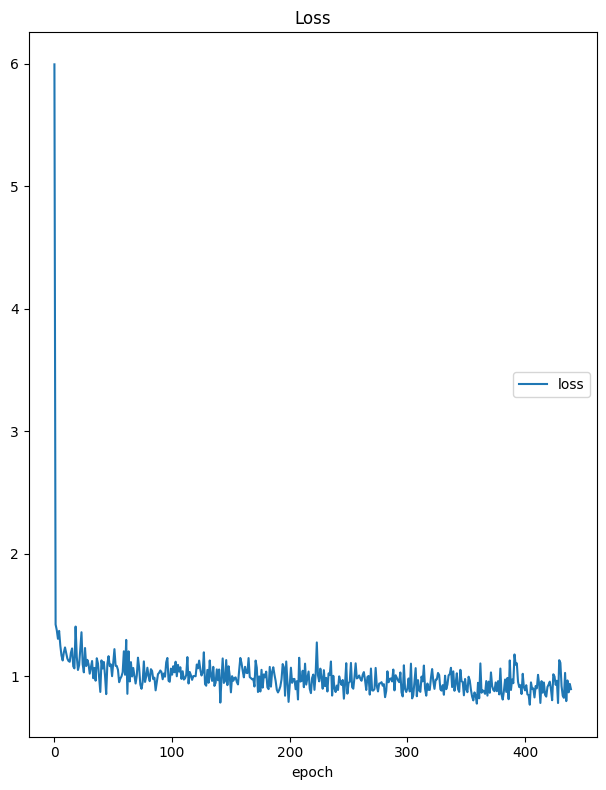

Loss
	loss             	 (min:    0.766, max:    5.993, cur:    0.893)
[Epoch 10/10] [Batch 4300/4375] [Batch Loss: 0.8930]
--- Quarter-epoch reached. Saving checkpoint... ---
Current loss: 0.8828352689743042
Checkpoint saved to Google Drive
---Finished Epoch 10, Avg Loss: 0.8988 ---


'/content/drive/MyDrive/COMP646_Final_Project/bdd100k_faster_rcnn_final.pth'

In [ ]:
"""
This cell was trained on an A100 GPU.
The A100 GPU has specialized hardware (Tensor Cores) to handle FP16 (half precision) numbers much faster.
"""

liveloss = PlotLosses()

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.02, momentum=0.9, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=8, gamma=0.5)

# multiplies gradients by a factor because FP16 has a smaller range than FP32, very small gradients can turn into zeros.
scaler = amp.GradScaler()

num_epochs = 10

quarter_mark = len(train_loader) // 4
liveloss_logs = {}
all_losses = []

for epoch in range(num_epochs):
    epoch_loss = 0
    for i, (images, targets) in enumerate(train_loader):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        # forward pass (use FP16)
        with amp.autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        # prevent vanishing gradients.
        scaler.scale(losses).backward()

        # shrink the gradients back before applying gradient clipping.
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # update scale factor for next batch.
        scaler.step(optimizer)
        scaler.update()

        current_loss = losses.item()
        epoch_loss += current_loss

        if i % 100 == 0:
          all_losses.append(current_loss)
          global_step = (epoch * len(train_loader)) + i
          liveloss_logs['loss'] = current_loss
          liveloss.update(liveloss_logs)
          liveloss.send()
          print(f"[Epoch {epoch+1}/{num_epochs}] [Batch {i}/{len(train_loader)}] [Batch Loss: {current_loss:.4f}]")

        if i > 0 and i % quarter_mark == 0:
          print("--- Quarter-epoch reached. Saving checkpoint... ---")
          print(f"Current loss: {current_loss}")
          checkpoint = {
              'epoch': epoch,
              'batch': i,
              'model_state_dict': model.state_dict(),
              'optimizer_state_dict': optimizer.state_dict(),
              'loss': losses.item(),
              'loss_history': all_losses,
              'scaler_state_dict': scaler.state_dict()
          }
          file_name = f"BDD100K_quarter_epoch_{epoch+1}_{i}.pth"
          torch.save(checkpoint, file_name)
          shutil.copy(file_name, f"/content/drive/MyDrive/COMP646_Final_Project/{file_name}")
          print("Checkpoint saved to Google Drive")

    scheduler.step()
    print(f"---Finished Epoch {epoch+1}, Avg Loss: {epoch_loss / len(train_loader):.4f} ---")

final_path = "bdd100k_faster_rcnn_final.pth"
torch.save(model.state_dict(), final_path)
shutil.copy(final_path, f"/content/drive/MyDrive/COMP646_Final_Project/{final_path}")

<h3>Evaluating the Model</h3>

In [17]:
metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')

# load the trained model
model = load_model('/content/drive/MyDrive/COMP646_Final_Project/BDD100K_quarter_epoch_10_4372.pth')

with torch.no_grad():
  for images, targets in val_loader:
    images = [img.to(device) for img in images]
    predictions = model(images)
    res_targets = [{k: v.to(device) for (k,v) in t.items()} for t in targets]
    metric.update(predictions, res_targets)

final_map = metric.compute()

print("\n--- Validation Results ---")
print(f"mAP @ 0.50:0.95: {final_map['map']:.4f}")
print(f"mAP @ 0.50:      {final_map['map_50']:.4f}")
print(f"mAP @ 0.75:      {final_map['map_75']:.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 238MB/s]



--- Validation Results ---
mAP @ 0.50:0.95: 0.3041
mAP @ 0.50:      0.5454
mAP @ 0.75:      0.2884


In [18]:
model = load_model('/content/drive/MyDrive/COMP646_Final_Project/BDD100K_quarter_epoch_10_4372.pth')

# Run a quick test on a single image from your val_loader
with torch.no_grad():
    images, targets = next(iter(val_loader))
    images, targets = next(iter(val_loader))
    images = [img.to(device) for img in images]
    predictions = model(images)

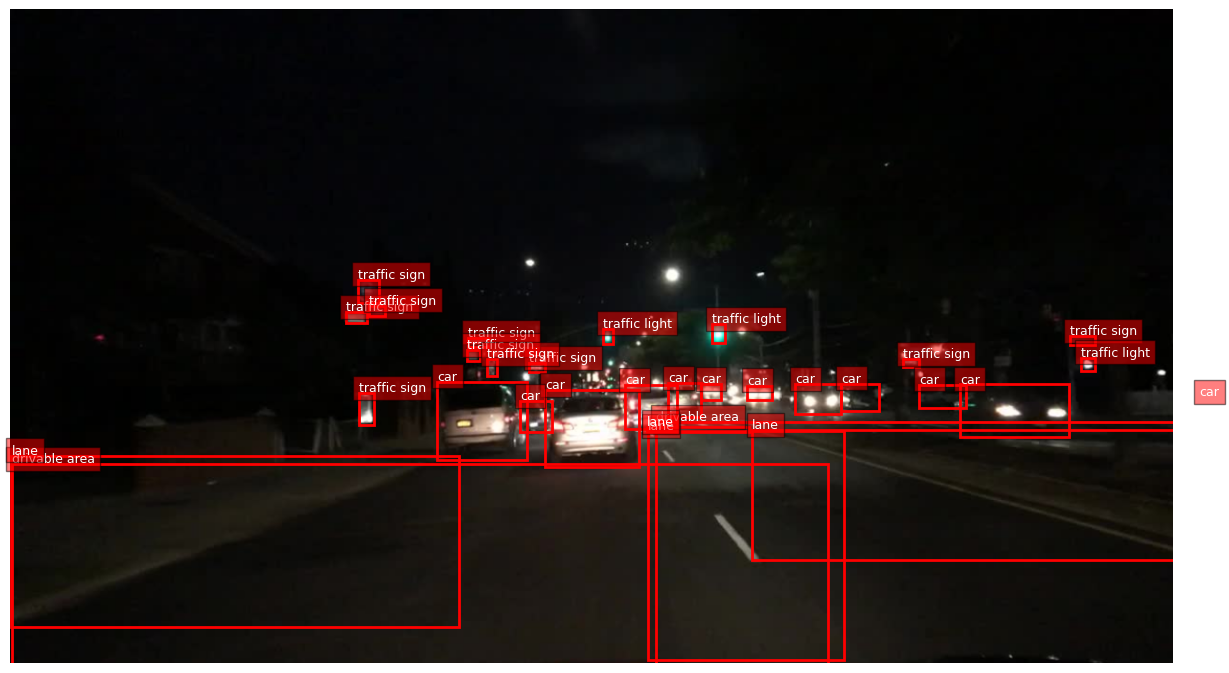

In [19]:
visualize_sample(images[3].cpu().permute(1, 2, 0).numpy(),
                 predictions[3]['boxes'].cpu().numpy().reshape(-1, 2, 2),
                 predictions[3]['labels'].cpu().numpy(),
                 predictions[3]['scores'].cpu().numpy())